In [9]:
import numpy as np
import matplotlib.pyplot as plt

def quantize(float_value, min_range, max_range, zero = 0):
    S = (max_range - min_range) / (np.power(2, 8) - 1)
    float_value /= S
    return float_value.astype(np.int8)

def to_float(uint_values, min_range, max_range):
    S = (max_range - min_range) / (np.power(2, 8) - 1)
    return uint_values.astype(np.float32) * S

def display_error_histogram(values, min_range, max_range):
    q_values = quantize(values, min_range, max_range)
    reconstructed = to_float(q_values, min_range, max_range)
    errors = values - reconstructed

    plt.figure(figsize=(6,4))
    plt.hist(errors, bins=50, color='gray', edgecolor='black')
    plt.title(f"Histogramme des erreurs de quantization\n(min={min_range}, max={max_range})")
    plt.xlabel("Erreur")
    plt.ylabel("Fréquence")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()


def quantization_error_stats(values, min_range, max_range):
    q_values = quantize(values, min_range, max_range)
    reconstructed = to_float(q_values, min_range, max_range)
    errors = values - reconstructed
    mean_error = np.mean(errors)
    std_error = np.std(errors)
    return mean_error, std_error

def study_situation(description, values, min_range, max_range):
    print(f"\n--- {description} ---")
    mean, std = quantization_error_stats(values, min_range, max_range)
    print(f"Moyenne erreur : {mean:.6f}, Ecart-type : {std:.6f}")
    display_error_histogram(values, min_range, max_range)


--- Situation 1 : valeurs entre 0 et 0.5, quantization [0,1] ---
Moyenne erreur : 61.810239, Ecart-type : 37.145483


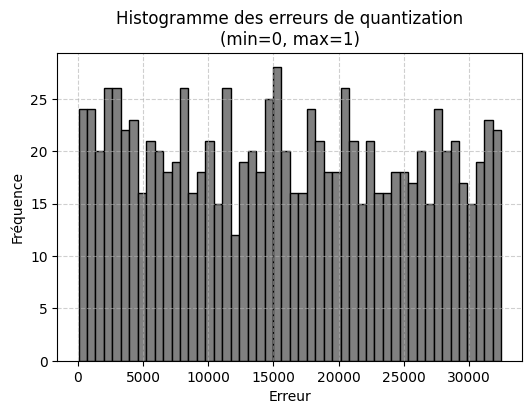


--- Situation 1 bis : valeurs entre 0 et 1, quantization [0,1] ---
Moyenne erreur : 125.407482, Ecart-type : 72.589821


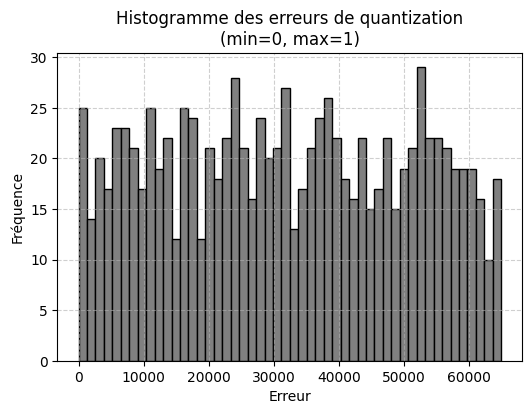


--- Situation 2 : valeurs entre 0 et 2, quantization [0,1] ---
Moyenne erreur : 253.123726, Ecart-type : 143.675290


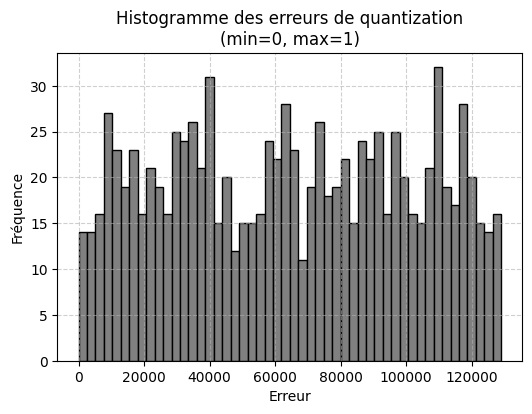


--- Situation 3 : valeurs entre 100 et 101, quantization [0,1000] ---
Moyenne erreur : -72.411726, Ecart-type : 0.073286


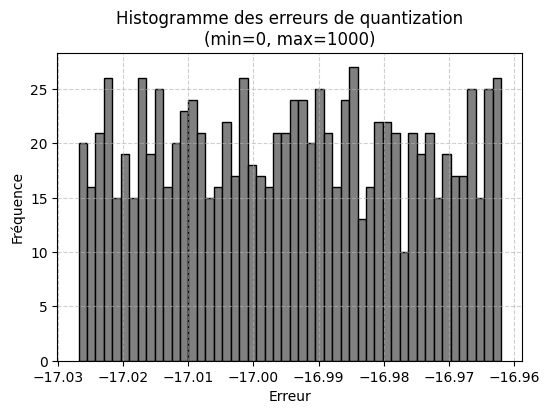


--- Situation 4 : valeurs gaussiennes autour de 0, quantization [-1,1] ---
Moyenne erreur : -0.897467, Ecart-type : 26.596778


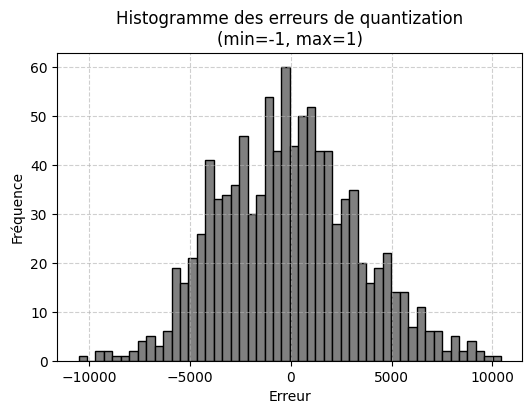


--- Situation 5 : distribution log-normale, quantization [0,5] ---
Moyenne erreur : 57.806143, Ecart-type : 29.871131


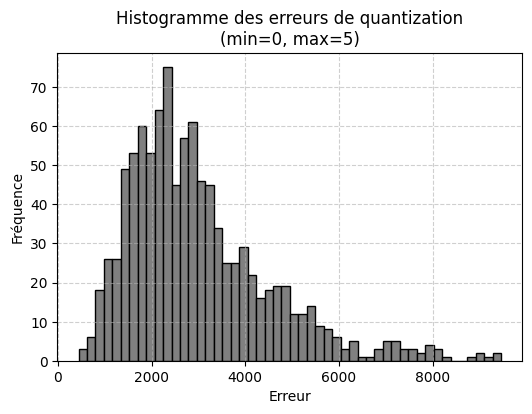


--- Situation 6 : plage dynamique, quantization [0,1] ---
Moyenne erreur : 127.443239, Ecart-type : 1.920192


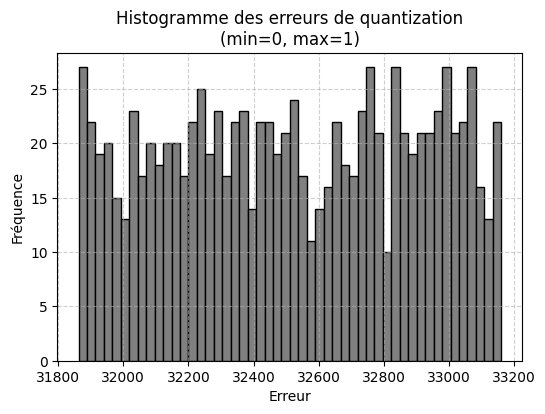

In [11]:
values1 = np.random.uniform(0, 0.5, 1000)
study_situation("Situation 1 : valeurs entre 0 et 0.5, quantization [0,1]", values1, 0, 1)

values1bis = np.random.uniform(0, 1, 1000)
study_situation("Situation 1 bis : valeurs entre 0 et 1, quantization [0,1]", values1bis, 0, 1)

values2 = np.random.uniform(0, 2, 1000)
study_situation("Situation 2 : valeurs entre 0 et 2, quantization [0,1]", values2, 0, 1)

values3 = np.random.uniform(100, 101, 1000)
study_situation("Situation 3 : valeurs entre 100 et 101, quantization [0,1000]", values3, 0, 1000)

values4 = np.random.normal(0, 0.2, 1000)
study_situation("Situation 4 : valeurs gaussiennes autour de 0, quantization [-1,1]", values4, -1, 1)

values5 = np.random.lognormal(0, 0.5, 1000)
study_situation("Situation 5 : distribution log-normale, quantization [0,5]", values5, 0, 5)

values6 = np.random.uniform(0.49, 0.51, 1000)
study_situation("Situation 6 : plage dynamique, quantization [0,1]", values6, 0, 1)